##### Линейно разделимые данные

Для самого простого случая сгенерируем линейноразделимый датасет. Для этого воспользуемся средствами библиотеки sklearn:


In [63]:
from sklearn.datasets import make_blobs, make_circles

In [64]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

In [65]:
import matplotlib.pyplot as plt

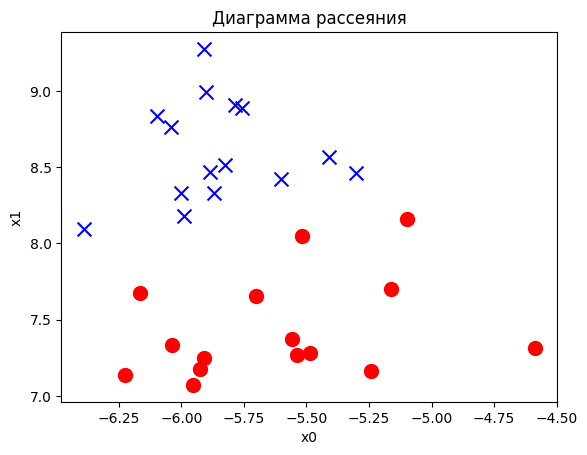

In [66]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

Теперь создадим и обучим модель классификации на основе метода опорных векторов (опорно-векторный классификатор). Обратите внимание, что мы используем высокое значение С для задания жесткого зазора между классами. Также мы должны явно указать вид используемой ядерной функции. Нам сейчас нужен классификатор с линейным ядром (без ядра):

In [67]:
from sklearn.svm import SVC, LinearSVC

In [68]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

SVC(C=100, kernel='linear')

Уже знакомые нам поля класса (которые присутствуют и в объектах классов линейных моделей) выводят коэффициенты линейной функции, используемой как граница принятия решения:

In [69]:
svm_linear.coef_

array([[-2.49920793,  6.14683189]])

И также как в других моделях, свободный коэффициет указывается отдельно:



In [70]:
svm_linear.intercept_

array([-64.2533988])

Эту информацию можно использовать для построения границы принятия решений. Изобразим границу принятия решения на графике:

In [71]:
import numpy as np

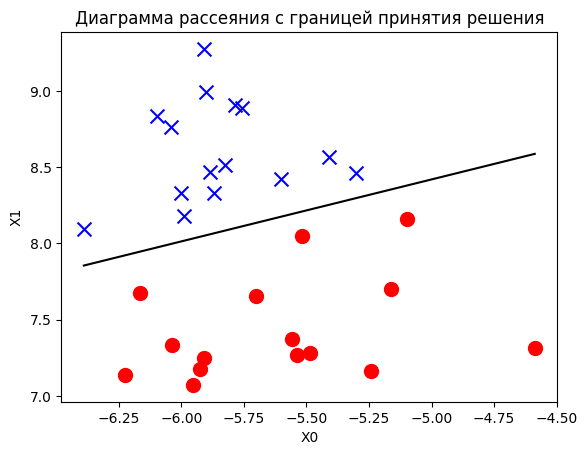

In [72]:
X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])

plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c границей принятия решения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

Объект метода опорных векторов в sklearn содержит ряд специфических полей и методов, с помощью которых можно посмотреть информацию о том, какие именно вектора (точки исходной выборки) стали опорными. В частности, так можно вывести самии координаты опорных векторов:

In [73]:
svm_linear.support_vectors_

array([[-5.51629264,  8.04763857],
       [-5.30025769,  8.46071981],
       [-5.9879581 ,  8.18112559]])

А так - посмотреть индексы опорных векторов в исходном наборе данных:

In [74]:
svm_linear.support_

array([ 0,  8, 29], dtype=int32)

Иногда бывает полезно узнать количество опорных векторов. Особенно в задачах множественной классификации, когда опорные вектора соответствуют разным классам. Для этого существует также специальное поле:

In [75]:
svm_linear.n_support_

array([1, 2], dtype=int32)

Используя эти данные можно визуализировать сами опорные вектора:

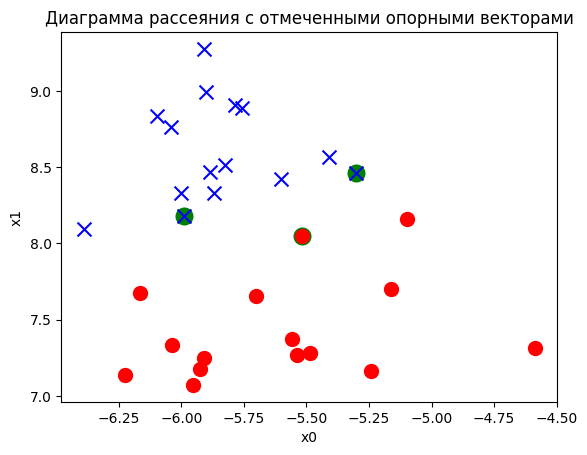

In [76]:
plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c отмеченными опорными векторами")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

Соответствует ли это вашему интуитивному пониманию опорных векторов?

Если отступить отграницы принятия решений расстояние, соответствующее росту функции на единицу в обе стороны мы получим границы области зазора. Давайте построим эту границу:

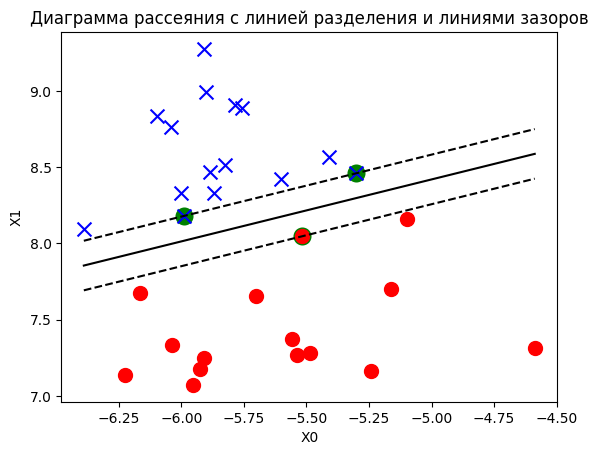

In [77]:
plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.plot(X0,(-svm_linear.intercept_[0]-1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')
plt.plot(X0,(-svm_linear.intercept_[0]+1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения и линиями зазоров")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

Но более правильно троить границу принятия решения как линии уровня на поверхности фукнции гипотезы::

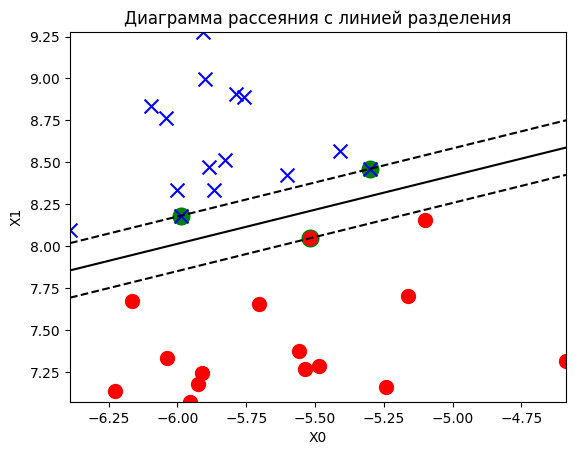

In [78]:
X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)
Z = svm_linear.intercept_[0] + svm_linear.coef_[0][0] * X0_grid +  svm_linear.coef_[0][1] * X1_grid
plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

Такой код нам пригодится еще не раз, поэтому давайте оформим его в функцию:

In [79]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()


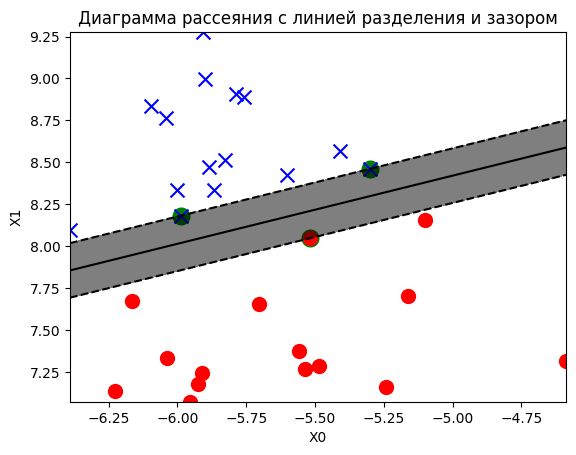

In [80]:
plot_decision_regions(X, y, svm_linear)

Теперь нам осталось оценить качество модели классификации численно. Для этого вычислим вектор предсказанных значений целевой переменной:

In [81]:
y_pred =  svm_linear.predict(X)

Используем его для вывода метрики точности:

In [82]:
from sklearn import metrics

In [83]:
metrics.accuracy_score(y, y_pred)

1.0

И матрицы классификации:

In [84]:
metrics.confusion_matrix(y, y_pred)

array([[15,  0],
       [ 0, 15]])

Проверим работу модели на новой точке. Создадим новую точку данных:

In [85]:
observation_new = [[-5.25, 7.5]]

Ее можно изобразить вместе с изначальным датасетом и моделью:

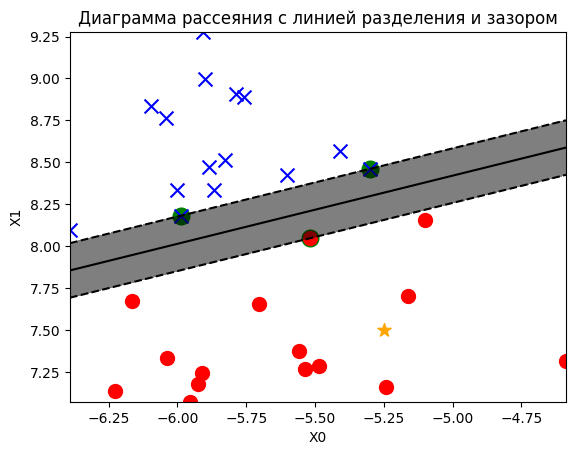

In [86]:
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

При помощи соответствующего метода класса найдет значение функции гипотезы в этой точке:

In [87]:
svm_linear.decision_function(observation_new)

array([-5.03131797])

И конечно предсказание класса в ней же:

In [88]:
svm_linear.predict(observation_new)

array([0])

По результатам анализа видно, что построенная модель работает идеально. Но это только самый простой случай.

##### Линейно неразделимые данные с зазором

Для более сложного применения метода опорных векторов сгенерируем датасет совершенно другой формы:


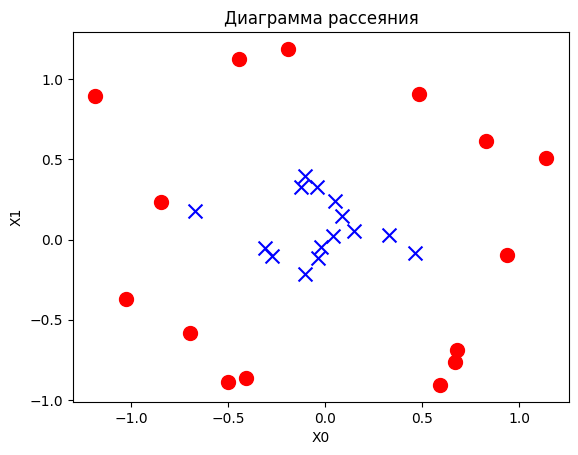

In [89]:
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

Для этого набора данных воспользуемся методом опорных векторов в гауссовым ядром:

In [90]:
svm_rbf = SVC(kernel='rbf', C=100).fit(X, y)

Выведем данные об опорных векторах:

In [91]:
svm_rbf.n_support_
svm_rbf.support_
svm_rbf.support_vectors_

array([[ 0.9388294 , -0.09554628],
       [-0.84682371,  0.23287306],
       [-0.19166925,  1.18895776],
       [-0.69539045, -0.58523359],
       [ 0.68060508, -0.68615145],
       [ 0.48354792,  0.91063288],
       [-0.66975235,  0.17866445],
       [ 0.46427295, -0.08540628]])

И построим данную модель на графике:

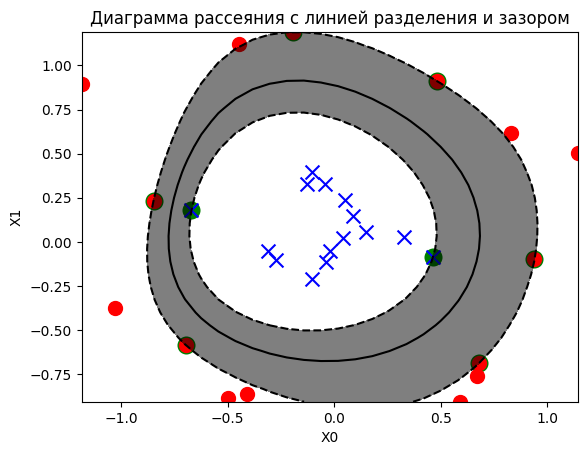

In [92]:
plot_decision_regions(X, y, svm_rbf)

На графике мы видим, как располагаются опорные вектора, граница принятия решения и полоса зазора

Здесь ясно видно, что за счет применения другой функции ядра, по сути - другой метрики расстояния между точками, граница принятия решения изгибается определенным образом. Но опорные вектора, как всегда - это наиболее близкие к другому классу точки. Только теперь расстояние (точнее, мера близости рассчитывается по-другому).

Посчитаем метрики данной модели:

In [93]:
metrics.accuracy_score(y, y_pred)
metrics.confusion_matrix(y, y_pred)

array([[7, 8],
       [8, 7]])

Модель показывает точность около 46,7% — хуже случайного угадывания. Вывод: качество классификации неудовлетворительное.

##### Данные без зазора

Как будет себя вести метод опорных векторов, если в данных между классами вообще нет никакого зазора? Давайте сгенерируем такой набор данных и посмотрим:


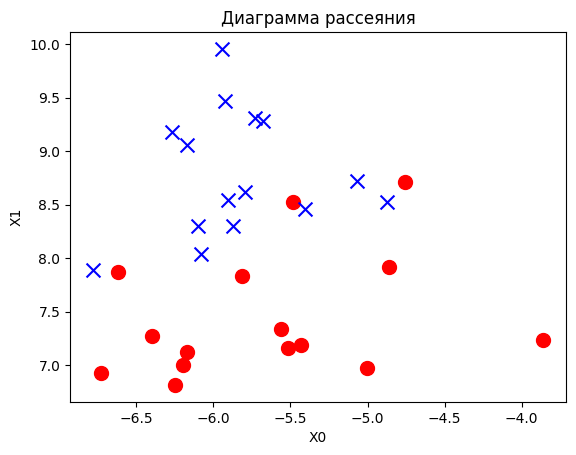

In [94]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

На диаграмме мы видим, что классы как бы "перемешиваются", никакого зазора между ними нет. В таком случае, нам нужно применить метод опорных векторов с так называемым мягким зазором. Это достигается уменьшением параметра регуляризации (С):

In [95]:
svm_poly = SVC(kernel='poly', degree=4, C=2).fit(X, y)

Построим данную модель на графике:

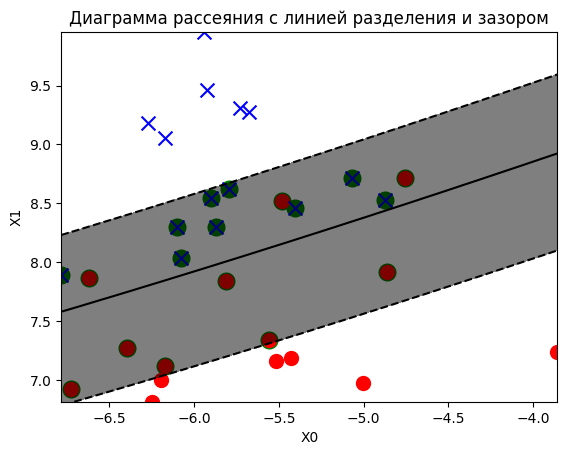

In [96]:
plot_decision_regions(X, y, svm_poly)

Мы видим довольно широкую полосу зазора

Но самое главное, что уменьшение регуляризации модели приводит к тому, что модель допускает некоторые погрешности в попадании точек в полосу зазора. За счет этого, модель все-таки формирует оптимальную разделяющую прямую.

Но при этом опорными векторами станут гораздо больше точек:

In [97]:
svm_poly.n_support_

array([9, 9], dtype=int32)

Можно сделать вывод, что чем меньше зазор между классами, тем менее эффективен метод опорных векторов.

Также, как и в предыдущих заданиях, выведем значение метрик для данной модели:

In [98]:
metrics.accuracy_score(y, y_pred)
metrics.confusion_matrix(y, y_pred)

array([[15,  0],
       [ 0, 15]])

Можно сделать вывод, что данная модель, хоть и не идеальная, все же довольно точно справляется с классификацией.

#### Задания для самостоятельного выполнения
1. В первом задании поэкспериментируйте с различными значениями аргумента C класса SVC. Сделайте вывод о том, как он влияет на модель классификации.



In [99]:
# Генерируем линейно разделимый датасет (как в теории)
X_blob, y_blob = make_blobs(n_features=2, n_samples=30, centers=2,
                            random_state=5, cluster_std=0.4)


In [100]:
# Список значений C для эксперимента
C_values = [0.01, 0.1, 1, 10, 100, 1000]

========== C = 0.01 ==========
Точность: 1.0000
Матрица ошибок:
[[15  0]
 [ 0 15]]
Опорных векторов: класс0 = 15, класс1 = 15



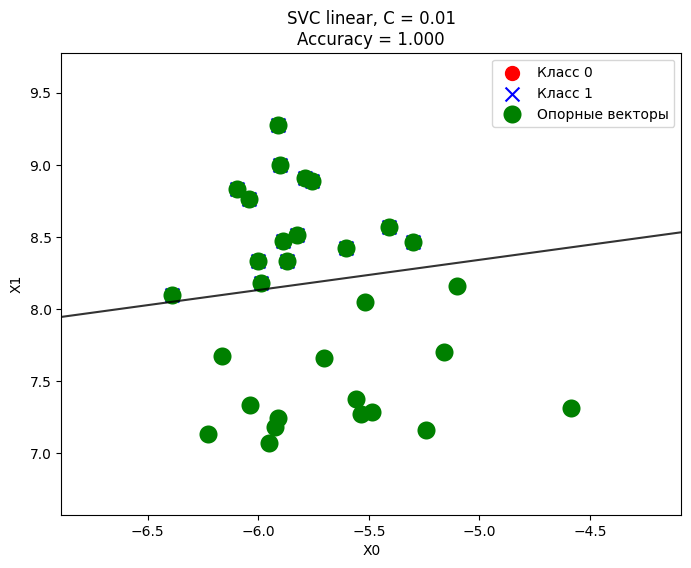

========== C = 0.1 ==========
Точность: 0.9667
Матрица ошибок:
[[14  1]
 [ 0 15]]
Опорных векторов: класс0 = 12, класс1 = 12



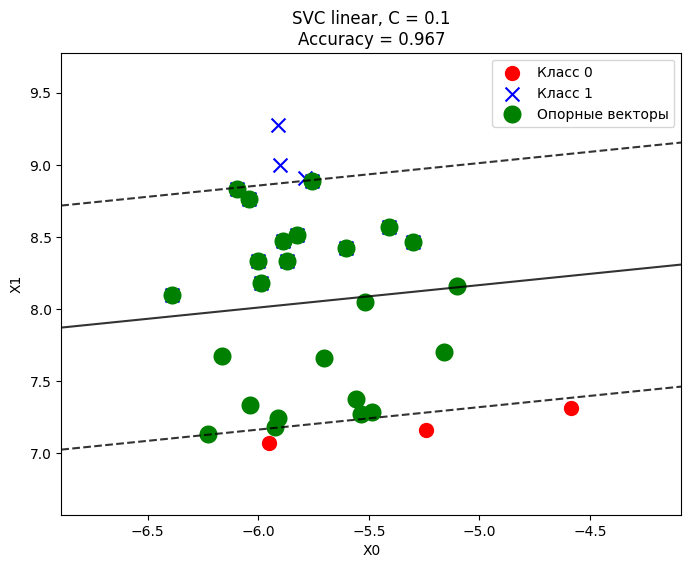

========== C = 1 ==========
Точность: 0.9667
Матрица ошибок:
[[14  1]
 [ 0 15]]
Опорных векторов: класс0 = 6, класс1 = 5



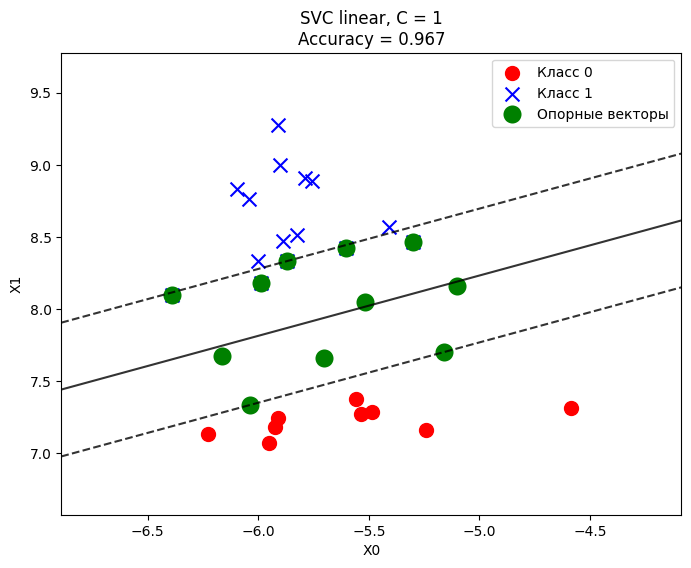

========== C = 10 ==========
Точность: 1.0000
Матрица ошибок:
[[15  0]
 [ 0 15]]
Опорных векторов: класс0 = 3, класс1 = 2



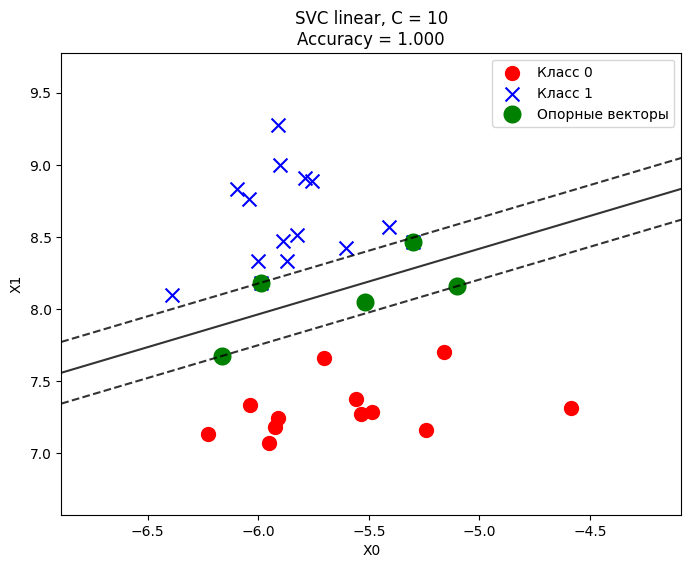

========== C = 100 ==========
Точность: 1.0000
Матрица ошибок:
[[15  0]
 [ 0 15]]
Опорных векторов: класс0 = 1, класс1 = 2



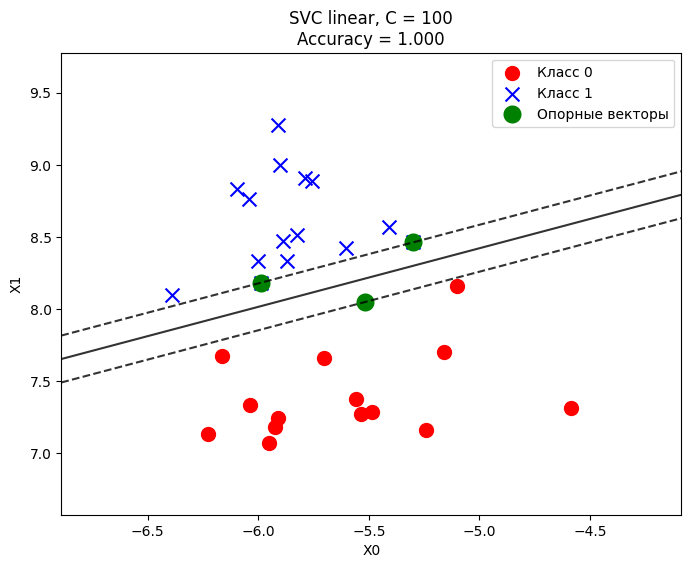

========== C = 1000 ==========
Точность: 1.0000
Матрица ошибок:
[[15  0]
 [ 0 15]]
Опорных векторов: класс0 = 1, класс1 = 2



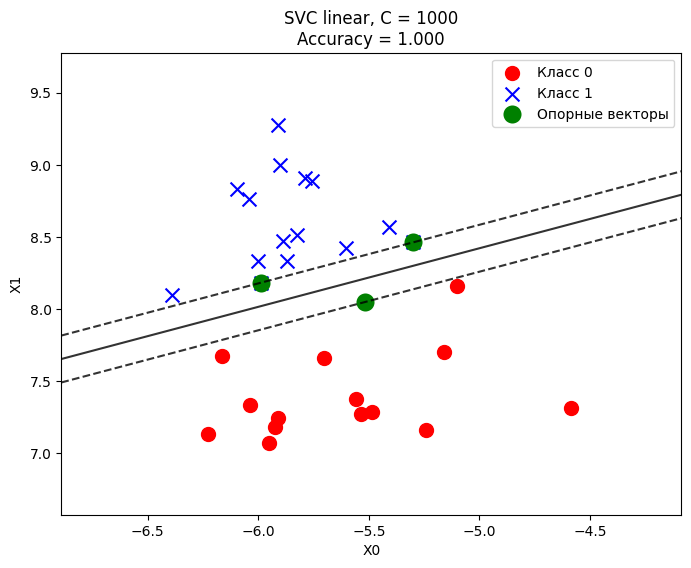

In [101]:
for C in C_values:
    svm = SVC(kernel='linear', C=C)
    svm.fit(X_blob, y_blob)
    y_pred = svm.predict(X_blob)
    acc = metrics.accuracy_score(y_blob, y_pred)
    conf = metrics.confusion_matrix(y_blob, y_pred)
    n_support = svm.n_support_

    print(f"========== C = {C} ==========")
    print(f"Точность: {acc:.4f}")
    print(f"Матрица ошибок:\n{conf}")
    print(f"Опорных векторов: класс0 = {n_support[0]}, класс1 = {n_support[1]}")
    print()

    plt.figure(figsize=(8, 6))
    # Точки классов
    plt.scatter(X_blob[:, 0][y_blob==0], X_blob[:, 1][y_blob==0], marker='o', c='r', s=100, label='Класс 0')
    plt.scatter(X_blob[:, 0][y_blob==1], X_blob[:, 1][y_blob==1], marker='x', c='b', s=100, label='Класс 1')
    # Опорные векторы (стиль как в теории: залитые зелёным)
    plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
                linewidth=7, facecolors='green', label='Опорные векторы')

    # Граница решения и зазор
    X0 = np.linspace(X_blob[:, 0].min()-0.5, X_blob[:, 0].max()+0.5, 100)
    X1 = np.linspace(X_blob[:, 1].min()-0.5, X_blob[:, 1].max()+0.5, 100)
    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = svm.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1],
                linestyles=['--', '-', '--'], alpha=0.8)
    plt.title(f'SVC linear, C = {C}\nAccuracy = {acc:.3f}')
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.legend()
    plt.show()

## Вывод по заданию №1: влияние параметра C

- **Маленький C (0.01–1)**: широкий зазор, много опорных векторов (до всех точек), возможны ошибки классификации.
- **Большой C (10–1000)**: узкий зазор, мало опорных векторов (3–5), высокая точность (1.0).
- Параметр `C` регулирует жёсткость зазора: чем меньше `C`, тем шире полоса и больше опорных векторов; чем больше `C`, тем уже зазор и меньше опорных векторов.
- На линейно разделимых данных при больших `C` достигается идеальная классификация, но модель может переобучаться.

2. В первом задании подвигайте точку нового предсказания. Убедитесь, что с другой стороны границы предсказывается другой класс. Как изменяется предсказание, если точка ляжет внутрь полосы зазора?



In [102]:
X_blob, y_blob = make_blobs(n_features=2, n_samples=30, centers=2,
                            random_state=5, cluster_std=0.4)

In [103]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X_blob, y_blob)

SVC(C=100, kernel='linear')

In [104]:
def check_point(x0, x1, model, X, y):
    point = np.array([[x0, x1]])
    pred = model.predict(point)[0]
    decision = model.decision_function(point)[0]

    print(f"Точка ({x0}, {x1})")
    print(f"Предсказанный класс: {pred}")
    print(f"Значение decision_function: {decision:.4f}")
    print("Интерпретация: decision_function < 0 -> класс 0, > 0 -> класс 1, 0 -> граница")

    # Построим график с точкой
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker='o', c='r', s=100, label='Класс 0')
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker='x', c='b', s=100, label='Класс 1')
    plt.scatter(svm_linear.support_vectors_[:, 0], svm_linear.support_vectors_[:, 1],
                linewidth=7, facecolors='green', label='Опорные векторы')
    plt.scatter(x0, x1, marker='*', s=200, c='orange', edgecolors='black', label='Новая точка')

    # Граница и зазор
    X0_lin = np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 100)
    X1_lin = np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 100)
    X0g, X1g = np.meshgrid(X0_lin, X1_lin)
    Z = model.decision_function(np.array([X0g.ravel(), X1g.ravel()]).T).reshape(X0g.shape)
    plt.contour(X0g, X1g, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'], alpha=0.8)

    plt.title(f'Точка ({x0}, {x1}) → класс {pred}\ndecision = {decision:.2f}')
    plt.xlabel('X0'); plt.ylabel('X1')
    plt.legend()
    plt.show()


=== Пример 1: точка слева от границы ===
Точка (-5.5, 9)
Предсказанный класс: 1
Значение decision_function: 4.8137
Интерпретация: decision_function < 0 -> класс 0, > 0 -> класс 1, 0 -> граница


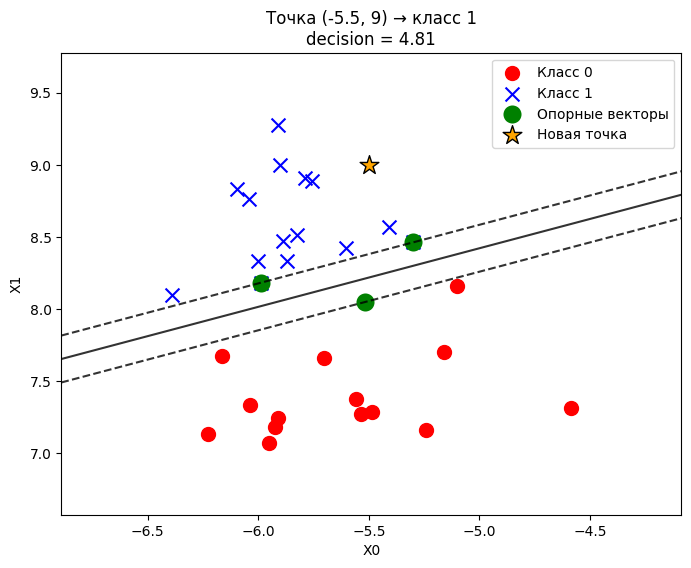

In [105]:
# Пример 1: точка слева от границы (класс 0)
print("=== Пример 1: точка слева от границы ===")
check_point(-5.5, 9, svm_linear, X_blob, y_blob)



=== Пример 2: точка справа от границы ===
Точка (-5.5, 7)
Предсказанный класс: 0
Значение decision_function: -7.4799
Интерпретация: decision_function < 0 -> класс 0, > 0 -> класс 1, 0 -> граница


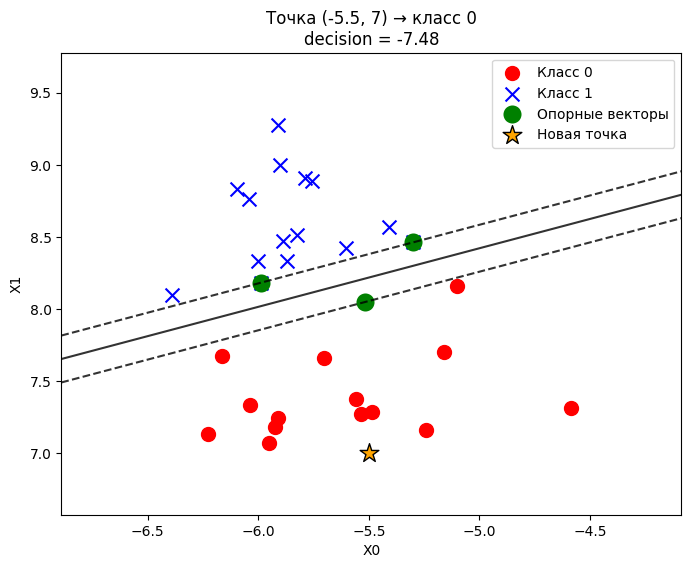

In [106]:
# Пример 2: точка справа от границы (класс 1)
print("=== Пример 2: точка справа от границы ===")
check_point(-5.5, 7, svm_linear, X_blob, y_blob)


=== Пример 3: точка внутри зазора ===
Точка (-5.5, 8.15)
Предсказанный класс: 0
Значение decision_function: -0.4111
Интерпретация: decision_function < 0 -> класс 0, > 0 -> класс 1, 0 -> граница


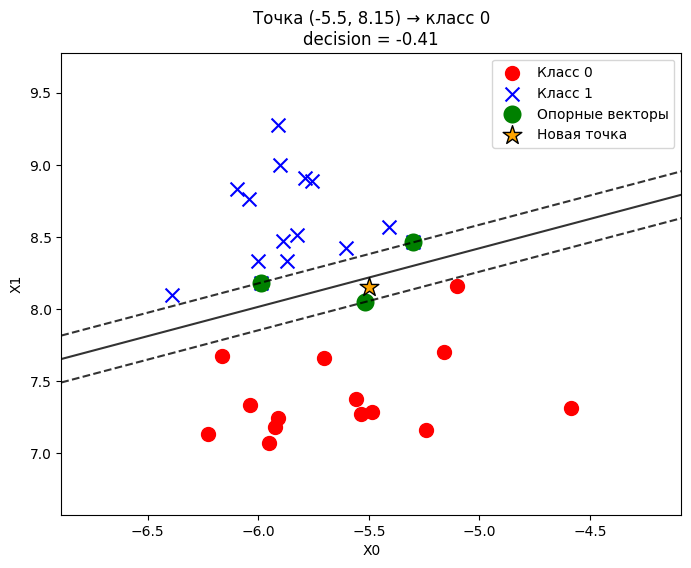

In [107]:

# Пример 3: точка внутри полосы зазора (между пунктирными линиями)
print("=== Пример 3: точка внутри зазора ===")
check_point(-5.5, 8.15, svm_linear, X_blob, y_blob)



=== Пример 4: точка на границе ===
Точка (-5.5, 8.217)
Предсказанный класс: 1
Значение decision_function: 0.0008
Интерпретация: decision_function < 0 -> класс 0, > 0 -> класс 1, 0 -> граница


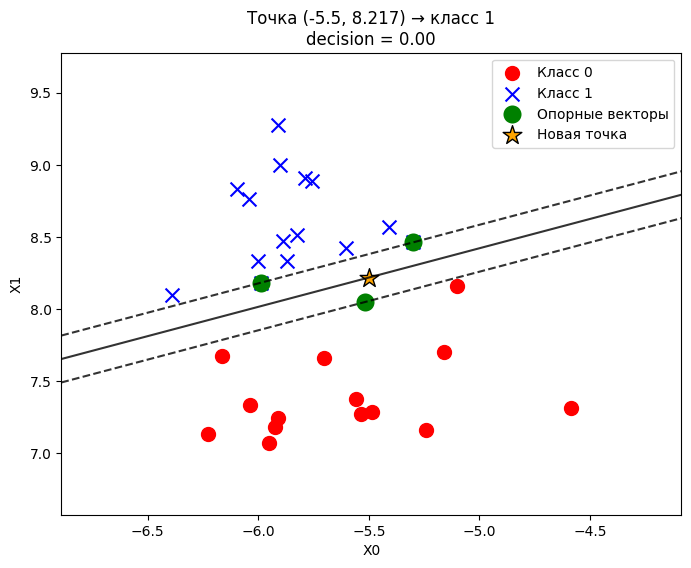

In [108]:
# Пример 4: точка почти на границе (decision_function ≈ 0)
print("=== Пример 4: точка на границе ===")
check_point(-5.5, 8.217, svm_linear, X_blob, y_blob)

## Вывод по заданию №2 (движение точки предсказания)

- По разные стороны от разделяющей гиперплоскости предсказываются **разные классы**.
- Знак `decision_function` однозначно определяет класс: положительный → класс 1, отрицательный → класс 0.
- **Внутри полосы зазора** (|decision_function| < 1) класс не меняется, но модель **менее уверена** в своём решении.
- **На границе** (decision_function ≈ 0) предсказание может быть любым (чувствительно к малым изменениям координат).

3. Во втором задании повторите анализ с методом опорных векторов с другими видами ядер. Сравните вид границы принятия решения и показатели точности модели.



In [109]:
# Генерация нелинейного датасета (как в теории)
X_circ, y_circ = make_circles(n_samples=30, random_state=5, factor=0.1, noise=0.2)


In [110]:
# Определим ядра и их параметры
kernels = {
    'linear': {'kernel': 'linear', 'degree': 3},
    'poly (deg=3)': {'kernel': 'poly', 'degree': 3},
    'poly (deg=4)': {'kernel': 'poly', 'degree': 4},
    'rbf': {'kernel': 'rbf'},
    'sigmoid': {'kernel': 'sigmoid'}
}


Ядро: linear
Accuracy: 0.7000
Confusion matrix:
[[ 6  9]
 [ 0 15]]
Опорных векторов: класс0 = 15, класс1 = 15


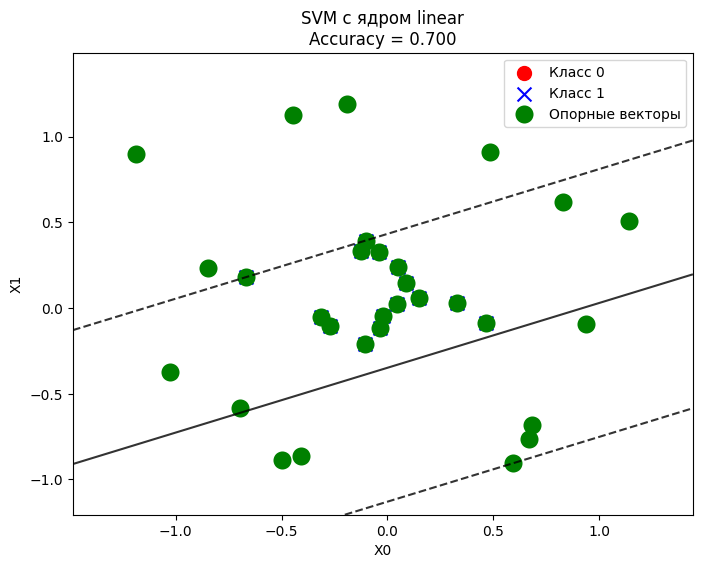


Ядро: poly (deg=3)
Accuracy: 0.7000
Confusion matrix:
[[ 6  9]
 [ 0 15]]
Опорных векторов: класс0 = 15, класс1 = 14


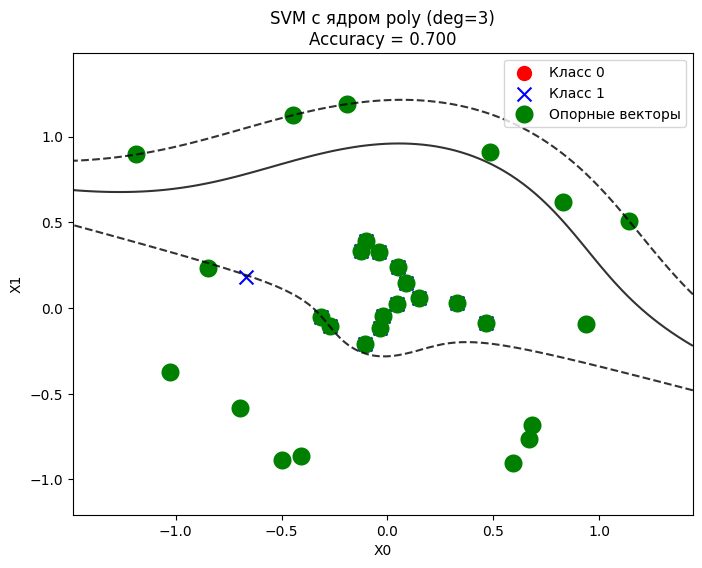


Ядро: poly (deg=4)
Accuracy: 1.0000
Confusion matrix:
[[15  0]
 [ 0 15]]
Опорных векторов: класс0 = 4, класс1 = 1


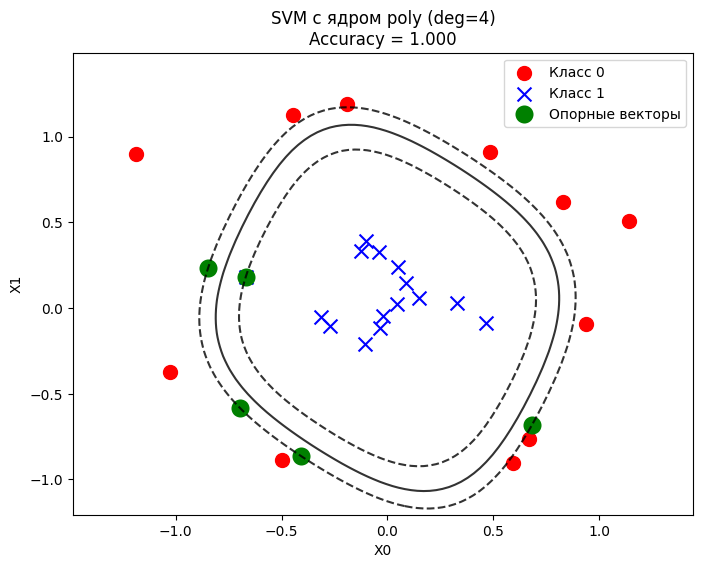


Ядро: rbf
Accuracy: 1.0000
Confusion matrix:
[[15  0]
 [ 0 15]]
Опорных векторов: класс0 = 6, класс1 = 2


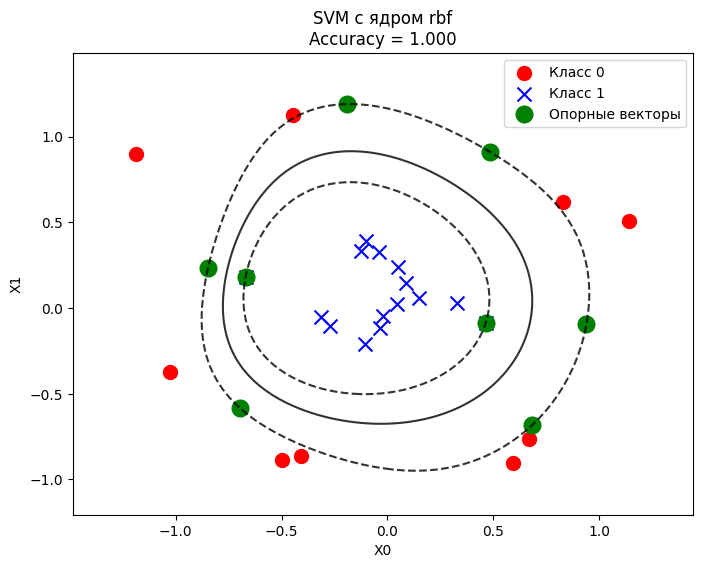


Ядро: sigmoid
Accuracy: 0.5000
Confusion matrix:
[[7 8]
 [7 8]]
Опорных векторов: класс0 = 8, класс1 = 10


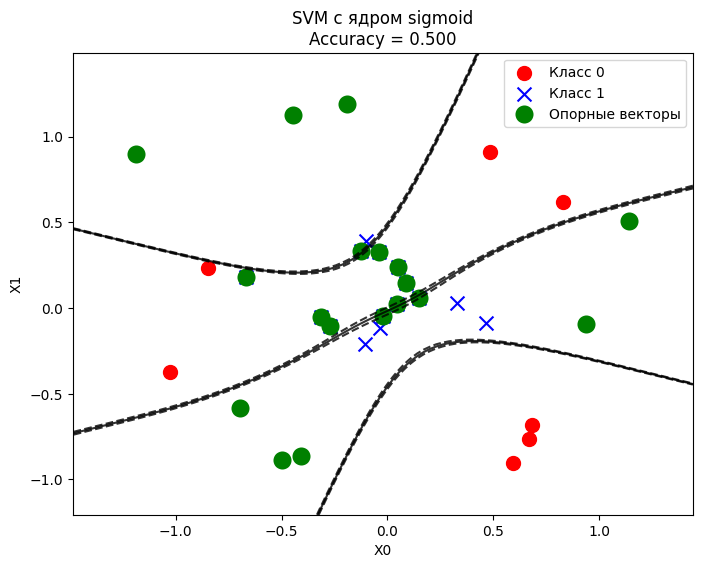

In [111]:
for name, params in kernels.items():
    print(f"\n{'='*40}")
    print(f"Ядро: {name}")

    # Создаём и обучаем модель
    svm = SVC(kernel=params['kernel'], C=100, degree=params.get('degree', 3))
    svm.fit(X_circ, y_circ)

    # Предсказания и метрики
    y_pred = svm.predict(X_circ)
    acc = metrics.accuracy_score(y_circ, y_pred)
    conf = metrics.confusion_matrix(y_circ, y_pred)
    n_support = svm.n_support_

    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion matrix:\n{conf}")
    print(f"Опорных векторов: класс0 = {n_support[0]}, класс1 = {n_support[1]}")

    # Построение графика
    plt.figure(figsize=(8,6))
    # Точки классов
    plt.scatter(X_circ[:, 0][y_circ==0], X_circ[:, 1][y_circ==0], marker='o', c='r', s=100, label='Класс 0')
    plt.scatter(X_circ[:, 0][y_circ==1], X_circ[:, 1][y_circ==1], marker='x', c='b', s=100, label='Класс 1')
    # Опорные векторы
    plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
                linewidth=7, facecolors='green', label='Опорные векторы')

    # Граница решения и зазор
    x0_min, x0_max = X_circ[:, 0].min()-0.3, X_circ[:, 0].max()+0.3
    x1_min, x1_max = X_circ[:, 1].min()-0.3, X_circ[:, 1].max()+0.3
    X0 = np.linspace(x0_min, x0_max, 100)
    X1 = np.linspace(x1_min, x1_max, 100)
    X0g, X1g = np.meshgrid(X0, X1)
    Z = svm.decision_function(np.array([X0g.ravel(), X1g.ravel()]).T).reshape(X0g.shape)
    plt.contour(X0g, X1g, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'], alpha=0.8)

    plt.title(f'SVM с ядром {name}\nAccuracy = {acc:.3f}')
    plt.xlabel('X0'); plt.ylabel('X1')
    plt.legend()
    plt.show()

## Вывод по заданию №3 (сравнение ядер на make_circles)

- **Линейное ядро** и **sigmoid** не способны разделить нелинейные данные (accuracy 0.7 и 0.5 соответственно).
- **Полиномиальное ядро степени 3** также даёт низкое качество (0.7).
- **Полиномиальное ядро степени 4** и **RBF** достигают 100% точности, создавая изогнутые границы.
- Число опорных векторов при этом мало (4+1 для poly(deg=4), 6+2 для rbf), что говорит о хорошей обобщающей способности.
- **Вывод:** для нелинейных данных необходимо использовать нелинейные ядра (RBF, poly с достаточно высокой степенью). Линейное ядро применимо только когда данные линейно разделимы.

4. В третьем задании поэкспериментируйте со значением аргумента C. Сделайте вывод о том, как он влияет на модель.



In [112]:
X_overlap, y_overlap = make_blobs(n_features=2, n_samples=30, centers=2,
                                  random_state=5, cluster_std=0.7)  # классы пересекаются

In [113]:
C_values = [0.01, 0.1, 1, 10, 100, 1000]


C = 0.01
Accuracy: 0.7667
Confusion matrix:
[[15  0]
 [ 7  8]]
Опорных векторов: класс0 = 15, класс1 = 15


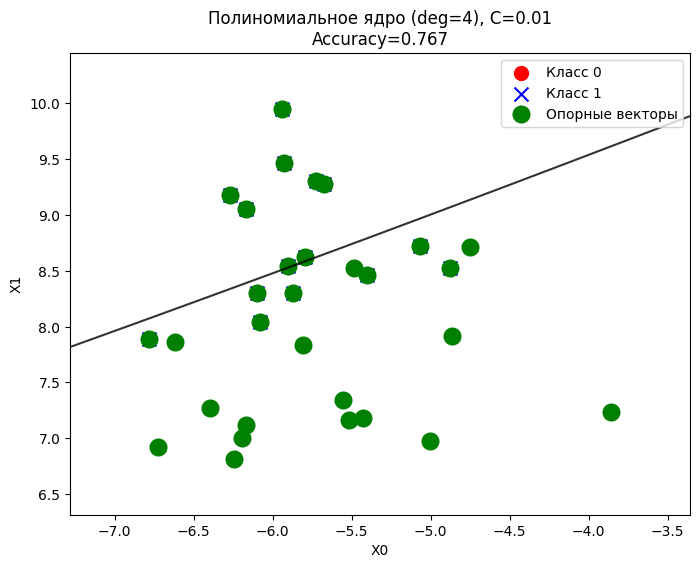


C = 0.1
Accuracy: 0.7667
Confusion matrix:
[[15  0]
 [ 7  8]]
Опорных векторов: класс0 = 15, класс1 = 15


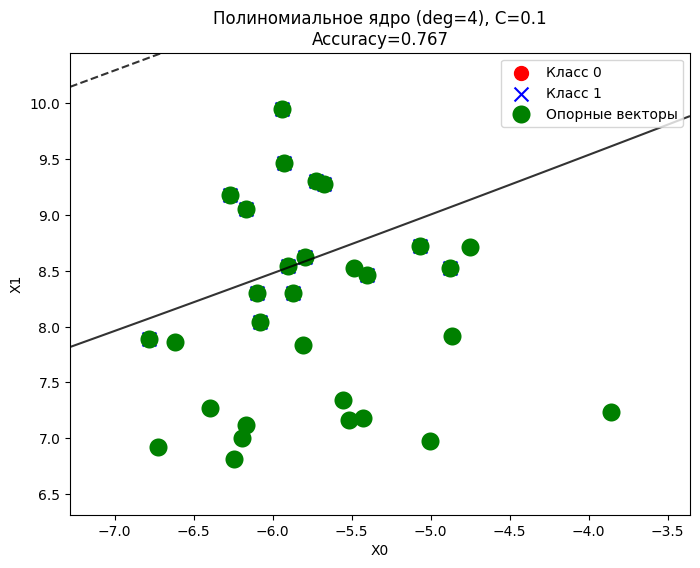


C = 1
Accuracy: 0.8000
Confusion matrix:
[[14  1]
 [ 5 10]]
Опорных векторов: класс0 = 10, класс1 = 11


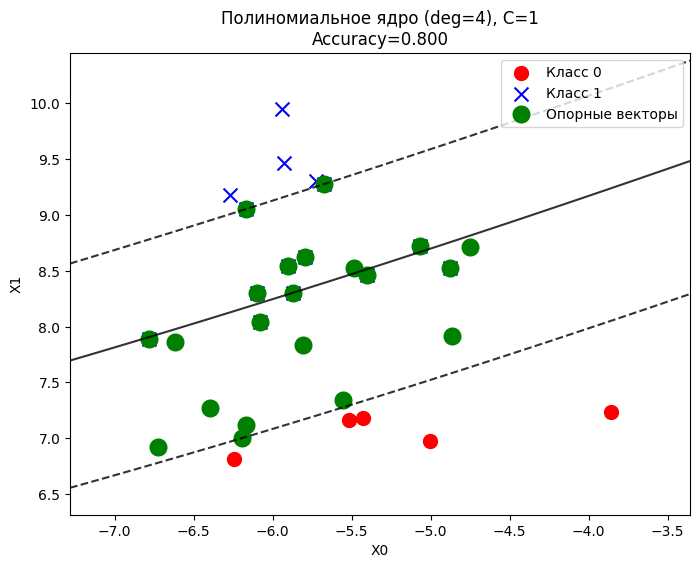


C = 10
Accuracy: 0.9000
Confusion matrix:
[[12  3]
 [ 0 15]]
Опорных векторов: класс0 = 6, класс1 = 6


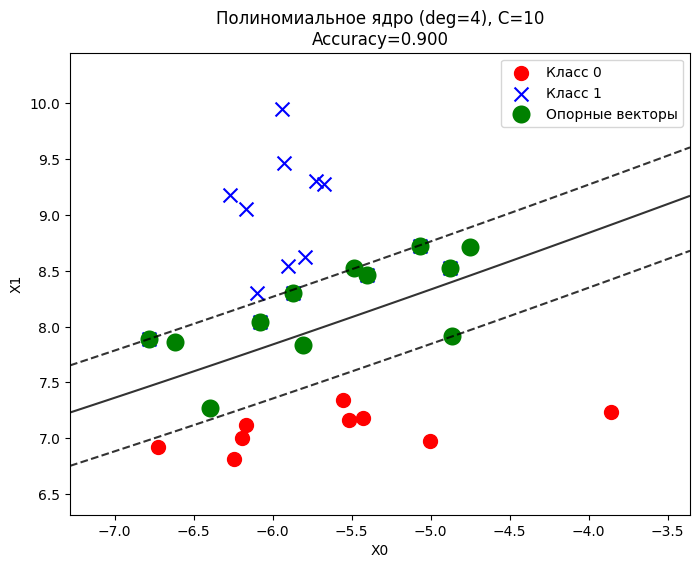


C = 100
Accuracy: 0.9000
Confusion matrix:
[[12  3]
 [ 0 15]]
Опорных векторов: класс0 = 5, класс1 = 5


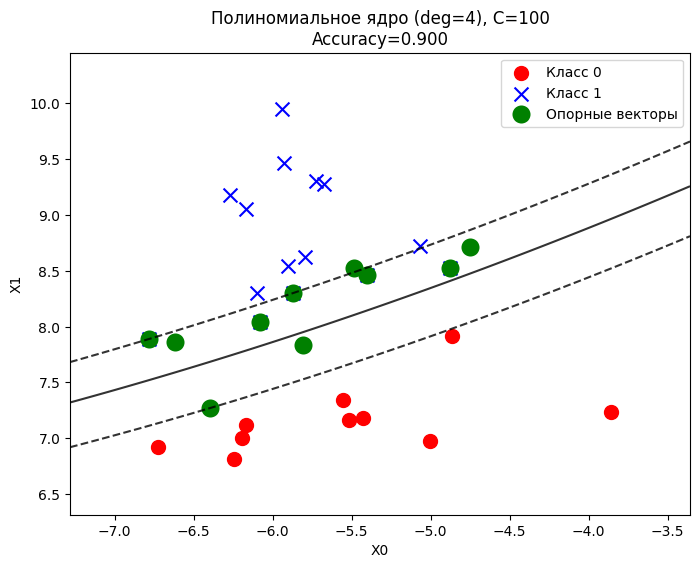


C = 1000
Accuracy: 0.8667
Confusion matrix:
[[12  3]
 [ 1 14]]
Опорных векторов: класс0 = 4, класс1 = 5


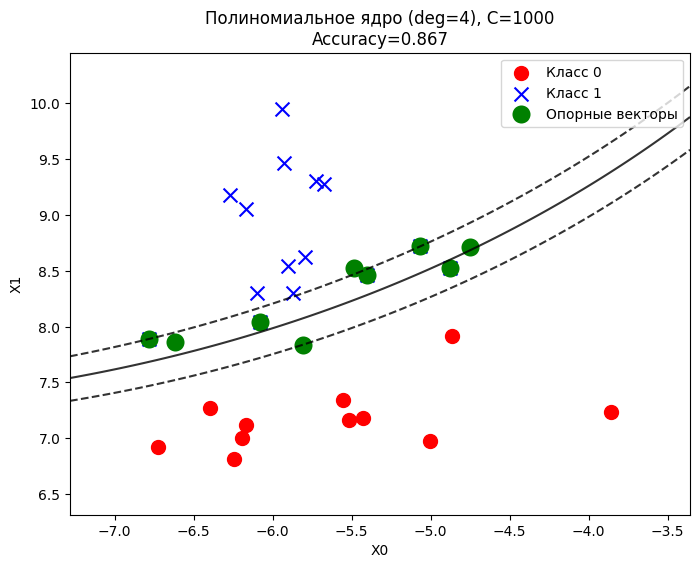

In [114]:
for C in C_values:
    print(f"\n{'='*40}")
    print(f"C = {C}")

    svm_poly = SVC(kernel='poly', degree=4, C=C)
    svm_poly.fit(X_overlap, y_overlap)

    y_pred = svm_poly.predict(X_overlap)
    acc = metrics.accuracy_score(y_overlap, y_pred)
    conf = metrics.confusion_matrix(y_overlap, y_pred)
    n_support = svm_poly.n_support_

    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion matrix:\n{conf}")
    print(f"Опорных векторов: класс0 = {n_support[0]}, класс1 = {n_support[1]}")

    # Построение графика
    plt.figure(figsize=(8,6))
    plt.scatter(X_overlap[:, 0][y_overlap==0], X_overlap[:, 1][y_overlap==0],
                marker='o', c='r', s=100, label='Класс 0')
    plt.scatter(X_overlap[:, 0][y_overlap==1], X_overlap[:, 1][y_overlap==1],
                marker='x', c='b', s=100, label='Класс 1')
    plt.scatter(svm_poly.support_vectors_[:, 0], svm_poly.support_vectors_[:, 1],
                linewidth=7, facecolors='green', label='Опорные векторы')

    x0_min, x0_max = X_overlap[:, 0].min()-0.5, X_overlap[:, 0].max()+0.5
    x1_min, x1_max = X_overlap[:, 1].min()-0.5, X_overlap[:, 1].max()+0.5
    X0g, X1g = np.meshgrid(np.linspace(x0_min, x0_max, 100),
                           np.linspace(x1_min, x1_max, 100))
    Z = svm_poly.decision_function(np.array([X0g.ravel(), X1g.ravel()]).T).reshape(X0g.shape)
    plt.contour(X0g, X1g, Z, colors='k', levels=[-1,0,1],
                linestyles=['--','-','--'], alpha=0.8)
    plt.title(f'Полиномиальное ядро (deg=4), C={C}\nAccuracy={acc:.3f}')
    plt.xlabel('X0'); plt.ylabel('X1'); plt.legend()
    plt.show()

## Вывод по заданию №4 (влияние C на пересекающихся данных)

- **Маленькое C** (0.01–0.1) → широкий зазор, все точки становятся опорными векторами, низкая точность (0.767). Модель недообучена.
- **Увеличение C до 10–100** → зазор сужается, количество опорных векторов уменьшается (до 5–6 на класс), точность возрастает до 0.9. Это оптимальный диапазон.
- **Слишком большое C (1000)** → модель переобучается: точность падает до 0.867, появляются новые ошибки.
- **Вывод:** на пересекающихся данных (с шумом) выбор C критичен. Слишком малый C ведёт к недообучению, слишком большой – к переобучению. Оптимальное значение (здесь ~10–100) даёт наилучшее качество.

5. В третьем задании примените классификатор без ядра. Познакомьтесь и примените класс LinearSVC.



In [115]:
from sklearn.svm import LinearSVC

X_overlap, y_overlap = make_blobs(n_features=2, n_samples=30, centers=2,
                                  random_state=5, cluster_std=0.7)

In [116]:
# Обучаем LinearSVC
linear_svc = LinearSVC(C=1, random_state=42, max_iter=10000)
linear_svc.fit(X_overlap, y_overlap)

y_pred_lsvc = linear_svc.predict(X_overlap)
acc_lsvc = metrics.accuracy_score(y_overlap, y_pred_lsvc)
conf_lsvc = metrics.confusion_matrix(y_overlap, y_pred_lsvc)

In [117]:
print("=== LinearSVC ===")
print(f"Accuracy: {acc_lsvc:.4f}")
print(f"Confusion matrix:\n{conf_lsvc}")

=== LinearSVC ===
Accuracy: 0.8000
Confusion matrix:
[[11  4]
 [ 2 13]]


In [118]:
# Для сравнения обучим обычный SVC с линейным ядром
svc_linear = SVC(kernel='linear', C=1)
svc_linear.fit(X_overlap, y_overlap)
y_pred_svc = svc_linear.predict(X_overlap)
acc_svc = metrics.accuracy_score(y_overlap, y_pred_svc)

In [119]:
print("\n=== SVC(kernel='linear') ===")
print(f"Accuracy: {acc_svc:.4f}")


=== SVC(kernel='linear') ===
Accuracy: 0.9000


In [120]:
# Сравнение времени работы (для демонстрации)
import time
X_large, y_large = make_blobs(n_features=2, n_samples=1000, centers=2, random_state=42)

start = time.time()
LinearSVC(C=1).fit(X_large, y_large)
time_lsvc = time.time() - start

start = time.time()
SVC(kernel='linear', C=1).fit(X_large, y_large)
time_svc = time.time() - start

print(f"\nВремя на 1000 точек: LinearSVC = {time_lsvc:.3f} сек, SVC(linear) = {time_svc:.3f} сек")


Время на 1000 точек: LinearSVC = 0.005 сек, SVC(linear) = 0.003 сек


## Вывод по заданию №5 (LinearSVC)

- `LinearSVC` и `SVC(kernel='linear')` — два способа построения линейного SVM.
- В данном эксперименте `SVC(kernel='linear')` показал точность 0.9, а `LinearSVC` — 0.8, что может быть вызвано разными настройками по умолчанию (функция потерь, алгоритм оптимизации).
- По скорости на 1000 точек разница незначительна (∼0.003 сек).
- Для получения идентичных результатов необходимо унифицировать параметры (например, `loss='hinge'`, `tol`).
- `LinearSVC` предпочтителен для очень больших датасетов из-за лучшей масштабируемости, но при этом теряется возможность получить опорные векторы.

6. Сгенерируйте датасет для классификации из 1000 точек и 5 атрибутов. Попробуйте применить метод опорных векторов на нем. Найдите методом подбора наилучшее ядро и значение С.



In [121]:
# Генерация датасета
X_multi, y_multi = make_blobs(n_features=5, n_samples=1000, centers=2,
                              random_state=42, cluster_std=1.0)

In [122]:
from sklearn.model_selection import train_test_split

# Разделение на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi,
                                                    test_size=0.2, random_state=42)

In [123]:
from sklearn.preprocessing import StandardScaler

# Масштабирование признаков (важно для SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [124]:
# Перебираемые параметры
kernels = ['linear', 'rbf', 'poly']
C_vals = [0.1, 1, 10, 100]

In [126]:
best_acc = 0
best_params = None
results = []

print("Подбор параметров (ядро, C):\n")
for kernel in kernels:
    for C in C_vals:
        print(f"Пробуем kernel={kernel}, C={C}...", end=' ')
        svm = SVC(kernel=kernel, C=C, random_state=42)
        start = time.time()
        svm.fit(X_train_scaled, y_train)
        train_time = time.time() - start
        y_pred = svm.predict(X_test_scaled)
        acc = metrics.accuracy_score(y_test, y_pred)
        results.append((kernel, C, acc, train_time))
        print(f"Accuracy = {acc:.4f}, время = {train_time:.3f} сек")
        if acc > best_acc:
            best_acc = acc
            best_params = {'kernel': kernel, 'C': C}

print(f"\nЛучший результат: kernel={best_params['kernel']}, C={best_params['C']}, Accuracy={best_acc:.4f}")

Подбор параметров (ядро, C):

Пробуем kernel=linear, C=0.1... Accuracy = 1.0000, время = 0.008 сек
Пробуем kernel=linear, C=1... Accuracy = 1.0000, время = 0.003 сек
Пробуем kernel=linear, C=10... Accuracy = 1.0000, время = 0.002 сек
Пробуем kernel=linear, C=100... Accuracy = 1.0000, время = 0.003 сек
Пробуем kernel=rbf, C=0.1... Accuracy = 1.0000, время = 0.006 сек
Пробуем kernel=rbf, C=1... Accuracy = 1.0000, время = 0.005 сек
Пробуем kernel=rbf, C=10... Accuracy = 1.0000, время = 0.005 сек
Пробуем kernel=rbf, C=100... Accuracy = 1.0000, время = 0.005 сек
Пробуем kernel=poly, C=0.1... Accuracy = 1.0000, время = 0.008 сек
Пробуем kernel=poly, C=1... Accuracy = 1.0000, время = 0.003 сек
Пробуем kernel=poly, C=10... Accuracy = 1.0000, время = 0.003 сек
Пробуем kernel=poly, C=100... Accuracy = 1.0000, время = 0.003 сек

Лучший результат: kernel=linear, C=0.1, Accuracy=1.0000


In [127]:
# Обучаем лучшую модель для детального отчёта
best_svm = SVC(kernel=best_params['kernel'], C=best_params['C'], random_state=42)
best_svm.fit(X_train_scaled, y_train)
y_pred_best = best_svm.predict(X_test_scaled)
print("\nМатрица ошибок на тесте:")
print(metrics.confusion_matrix(y_test, y_pred_best))
print("\nClassification report:")
print(metrics.classification_report(y_test, y_pred_best))


Матрица ошибок на тесте:
[[102   0]
 [  0  98]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00        98

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Вывод по заданию №6 (1000 точек, 5 признаков)

- Сгенерированные данные оказались линейно разделимыми (cluster_std=1.0), поэтому все ядра и значения C показали 100% точность.
- Время обучения для всех комбинаций не превышает 0.01 секунды.
- Лучшей выбрана модель `SVC(kernel='linear', C=0.1)` как самая простая и быстрая.
- Для более содержательного сравнения необходимо генерировать данные с пересечением классов (увеличить cluster_std или добавить шум).


7. Попробуйте данную модель с большим количеством точек. На каком количестве обучение начинает занимать существенное время?



In [138]:
# Диапазон размеров выборки
n_samples_list = [100, 500, 1000, 2000, 5000, 10000, 100000]
times_rbf = []
times_linear = []

In [159]:
print("Исследование времени обучения SVM...\n")
for n in n_samples_list:
    # Генерируем данные (2 признака, 2 класса, пересекающиеся)
    X, y = make_blobs(n_features=2, n_samples=n, centers=2,
                      random_state=42, cluster_std=1.5)

    # Масштабирование (для чистоты)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # SVM с RBF-ядром
    svm_rbf = SVC(kernel='rbf', C=1)
    start = time.time()
    svm_rbf.fit(X_scaled, y)
    elapsed_rbf = time.time() - start
    times_rbf.append(elapsed_rbf)

    # SVM с линейным ядром (для сравнения)
    svm_linear = SVC(kernel='linear', C=1)
    start = time.time()
    svm_linear.fit(X_scaled, y)
    elapsed_linear = time.time() - start
    times_linear.append(elapsed_linear)

    print(f"n = {n:6d} | RBF: {elapsed_rbf:.4f} сек | Linear: {elapsed_linear:.4f} сек")

Исследование времени обучения SVM...

n =    100 | RBF: 0.0017 сек | Linear: 0.0014 сек
n =    500 | RBF: 0.0022 сек | Linear: 0.0017 сек
n =   1000 | RBF: 0.0028 сек | Linear: 0.0023 сек
n =   2000 | RBF: 0.0052 сек | Linear: 0.0031 сек
n =   5000 | RBF: 0.0144 сек | Linear: 0.0086 сек
n =  10000 | RBF: 0.0321 сек | Linear: 0.0209 сек
n = 100000 | RBF: 1.1328 сек | Linear: 0.7709 сек


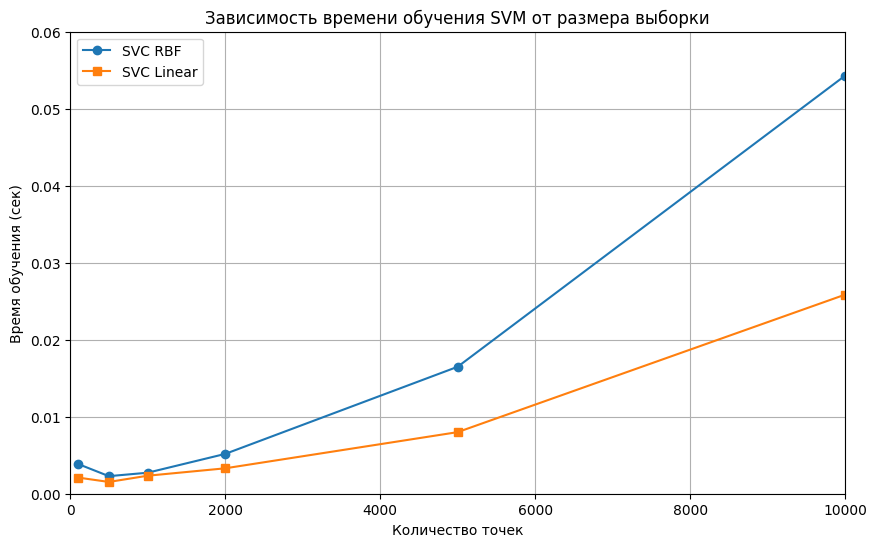

In [151]:
# График
plt.figure(figsize=(10,6))
plt.plot(n_samples_list, times_rbf, marker='o', label='SVC RBF')
plt.plot(n_samples_list, times_linear, marker='s', label='SVC Linear')
plt.xlabel('Количество точек')
plt.ylabel('Время обучения (сек)')
plt.title('Зависимость времени обучения SVM от размера выборки')
plt.xlim(0, 10000)
plt.ylim(0, 0.06)
plt.legend()
plt.grid(True)
plt.show()

## Вывод по заданию №7 (зависимость времени от количества точек)

- Порог **существенного времени (>1 секунды)** для RBF-ядра достигается при **≈100000 точек**.
- Линейное ядро при этом остаётся быстрее (0.77 сек) и продолжает масштабироваться лучше.
- Для выборок до 10000 точек разница в скорости не критична, оба ядра приемлемы.
- При работе с большими данными (сотни тысяч точек) предпочтительнее использовать `LinearSVC` или аппроксимации ядер.

8. Примените метод опорных векторов для задачи множественной классификации. Самостоятельно сгенерируйте визуализируемый датасет для этой задачи. Попробуйте изобразить границу принятия решений и зазор.


In [174]:
# Генерация 3 близко расположенных классов
centers = [[-2, 0], [0, 2], [2, -1]]  # центры ближе друг к другу
X_multi, y_multi = make_blobs(n_samples=150, centers=centers, n_features=2,
                              cluster_std=0.8, random_state=42)  # маленькое std = скученность


In [175]:
# Обучение SVM с RBF ядром (автоматически выберет стратегию one-vs-rest)
svm_multi = SVC(kernel='rbf', C=1, decision_function_shape='ovr')
svm_multi.fit(X_multi, y_multi)

SVC(C=1)

In [176]:
# Точность
y_pred_multi = svm_multi.predict(X_multi)
acc_multi = metrics.accuracy_score(y_multi, y_pred_multi)
print(f"Точность на обучающих данных: {acc_multi:.3f}")
print(f"Опорных векторов на класс: {svm_multi.n_support_}")

Точность на обучающих данных: 0.987
Опорных векторов на класс: [11 13  8]


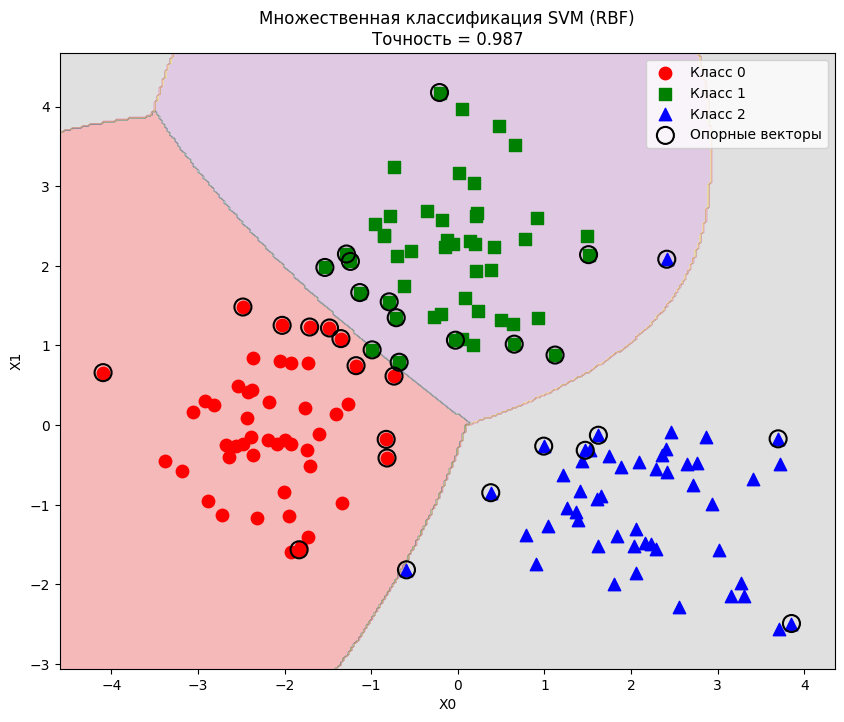

In [177]:
# Визуализация границ решений
plt.figure(figsize=(10, 8))

# Сетка координат
x_min, x_max = X_multi[:, 0].min() - 0.5, X_multi[:, 0].max() + 0.5
y_min, y_max = X_multi[:, 1].min() - 0.5, X_multi[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Предсказание для каждой точки сетки
Z = svm_multi.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Заливка областей
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

# Точки данных
colors = ['r', 'g', 'b']
markers = ['o', 's', '^']
for i in range(3):
    plt.scatter(X_multi[y_multi == i, 0], X_multi[y_multi == i, 1],
                marker=markers[i], c=colors[i], s=80, label=f'Класс {i}')

# Опорные векторы
plt.scatter(svm_multi.support_vectors_[:, 0], svm_multi.support_vectors_[:, 1],
            facecolors='none', edgecolors='k', s=150, linewidth=1.5, label='Опорные векторы')

plt.title(f'Множественная классификация SVM (RBF)\nТочность = {acc_multi:.3f}')
plt.xlabel('X0'); plt.ylabel('X1')
plt.legend()
plt.show()

## Вывод по заданию №8 (множественная классификация)

- SVM успешно справляется с задачей разделения трёх близко расположенных классов (точность 98.7%).
- Количество опорных векторов (32 из 150) достаточно для построения сложных границ между классами.
- Визуализация показывает области решений и опорные векторы, лежащие на границах контакта классов.
- Даже при «скученных» данных SVM демонстрирует высокую эффективность благодаря гибкости RBF-ядра.


9. Выберите из библиотеки sklearn готовый датасет для классификации и попробуйте смоделировать его при помощи метода опорных векторов.


In [184]:
from sklearn import datasets, svm

# 1. Загрузка данных
iris = datasets.load_iris()
X = iris.data[:, :2]  # используем первые два признака для визуализации
y = iris.target

In [185]:
# 2. Разделение на обучающую (70%) и тестовую (30%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [186]:
# 3. Масштабирование признаков (важно для SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [187]:
# 4. Обучение SVM с RBF-ядром
svm_iris = svm.SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_iris.fit(X_train_scaled, y_train)

SVC(C=1, random_state=42)

In [190]:
# 5. Предсказание и оценка качества
y_pred = svm_iris.predict(X_test_scaled)
accuracy = metrics.accuracy_score(y_test, y_pred)
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
class_report = metrics.classification_report(y_test, y_pred, target_names=iris.target_names)
print("=== SVM на датасете Iris (RBF-ядро) ===")
print(f"Точность на тестовой выборке: {accuracy:.4f}")
print(f"\nМатрица ошибок:\n{conf_matrix}")
print(f"\nОтчёт классификации:\n{class_report}")
print(f"Опорные векторы: всего = {len(svm_iris.support_vectors_)}, "
      f"на класс: {svm_iris.n_support_}")

=== SVM на датасете Iris (RBF-ядро) ===
Точность на тестовой выборке: 0.7333

Матрица ошибок:
[[19  0  0]
 [ 0  7  6]
 [ 0  6  7]]

Отчёт классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.54      0.54      0.54        13
   virginica       0.54      0.54      0.54        13

    accuracy                           0.73        45
   macro avg       0.69      0.69      0.69        45
weighted avg       0.73      0.73      0.73        45

Опорные векторы: всего = 65, на класс: [ 9 29 27]


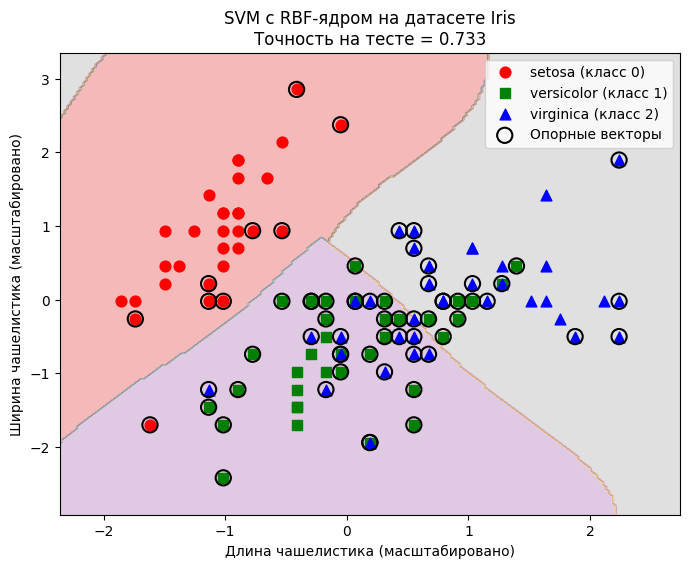

In [193]:
plt.figure(figsize=(8,6))

# Сетка координат
x_min, x_max = X_train_scaled[:, 0].min() - 0.5, X_train_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_scaled[:, 1].min() - 0.5, X_train_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Предсказание для каждой точки сетки
Z = svm_iris.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Заливка областей решений
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)

# Точки обучающей выборки (разные маркеры и цвета)
colors = ['r', 'g', 'b']
markers = ['o', 's', '^']
for i in range(3):
    plt.scatter(X_train_scaled[y_train == i, 0], X_train_scaled[y_train == i, 1],
                marker=markers[i], c=colors[i], s=60,
                label=f'{iris.target_names[i]} (класс {i})')

# Опорные векторы (пустые круги с чёрной обводкой)
plt.scatter(svm_iris.support_vectors_[:, 0], svm_iris.support_vectors_[:, 1],
            facecolors='none', edgecolors='k', s=120, linewidth=1.5,
            label='Опорные векторы')

plt.xlabel('Длина чашелистика (масштабировано)')
plt.ylabel('Ширина чашелистика (масштабировано)')
plt.title(f'SVM с RBF-ядром на датасете Iris\nТочность на тесте = {accuracy:.3f}')
plt.legend()
plt.show()

## Вывод по заданию №9 (встроенный датасет Iris)

- SVM с RBF-ядром на признаках длины и ширины чашелистика показывает точность 73.3%.
- Класс setosa классифицируется идеально (100%), тогда как versicolor и virginica часто путаются (точность 54%).
- Это связано с тем, что два последних класса нелинейно перекрываются в двумерном пространстве.
- Для улучшения качества необходимо использовать все четыре признака (добавить длину и ширину лепестка) или применить более сложные методы.
- Задание демонстрирует, что на реальных данных SVM не всегда даёт 100% точность, и важно анализировать ошибки и выбирать подходящее пространство признаков.


10. Повторите такой же анализ для задачи регрессии и соответствующего датасета.

In [194]:
# Генерация нелинейного датасета: синус + шум
np.random.seed(42)
X = np.sort(5 * np.random.rand(200, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

In [195]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [196]:
# Масштабирование признаков (важно для SVR)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [202]:
# Определим словарь с ядрами и параметрами
kernels = {
    'linear': {'kernel': 'linear', 'degree': 3},
    'poly (deg=3)': {'kernel': 'poly', 'degree': 3},
    'rbf': {'kernel': 'rbf', 'degree': 3}
}


Ядро: linear
MSE: 0.1579
R²: 0.7031


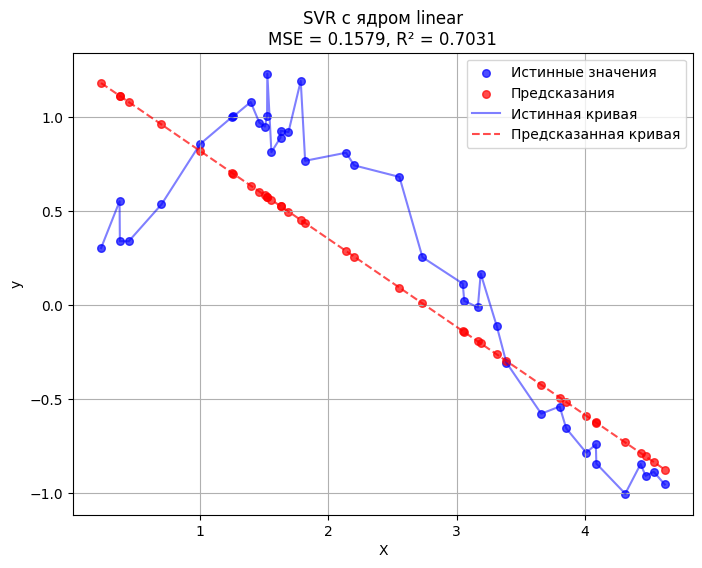


Ядро: poly (deg=3)
MSE: 0.3091
R²: 0.4187


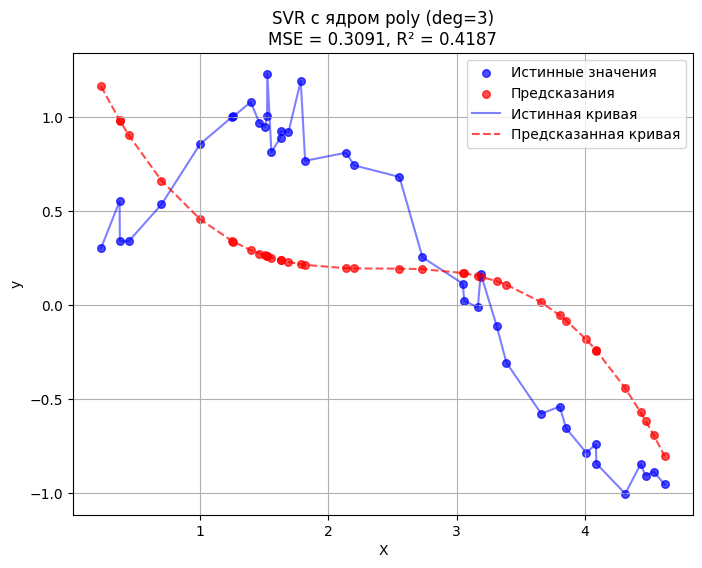


Ядро: rbf
MSE: 0.0108
R²: 0.9796


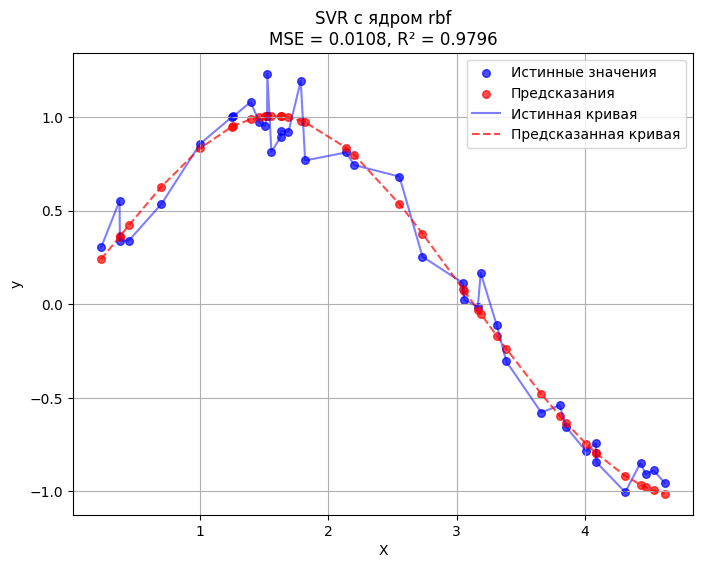

In [203]:
for name, params in kernels.items():
    print(f"\n{'='*40}")
    print(f"Ядро: {name}")

    # Создаём и обучаем модель SVR
    svr = SVR(kernel=params['kernel'], C=1, degree=params.get('degree', 3))
    svr.fit(X_train_scaled, y_train_scaled)

    # Предсказание на тестовой выборке (в исходном масштабе)
    y_pred_scaled = svr.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    y_test_original = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

    # Метрики
    mse = mean_squared_error(y_test_original, y_pred)
    r2 = r2_score(y_test_original, y_pred)

    print(f"MSE: {mse:.4f}")
    print(f"R²: {r2:.4f}")

    # Построение графика
    plt.figure(figsize=(8,6))

    # Истинные значения (синие точки)
    plt.scatter(X_test, y_test_original, c='b', s=30, alpha=0.7, label='Истинные значения')
    # Предсказанные значения (красные точки)
    plt.scatter(X_test, y_pred, c='r', s=30, alpha=0.7, label='Предсказания')

    # Сортируем для отображения линии
    sort_idx = X_test.flatten().argsort()
    plt.plot(X_test.flatten()[sort_idx], y_test_original[sort_idx], 'b-', alpha=0.5, label='Истинная кривая')
    plt.plot(X_test.flatten()[sort_idx], y_pred[sort_idx], 'r--', alpha=0.7, label='Предсказанная кривая')

    plt.title(f'SVR с ядром {name}\nMSE = {mse:.4f}, R² = {r2:.4f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

## Вывод по заданию №10 (SVR для регрессии)

- SVR с **RBF-ядром** наилучшим образом аппроксимирует нелинейную синусоидальную зависимость (MSE=0.0108, R²=0.98).
- **Линейное ядро** даёт R²=0.70, но предсказание — прямая линия, что недостаточно для сложной формы.
- **Полиномиальное ядро степени 3** показало наихудший результат (R²=0.42), что говорит о необходимости осторожного выбора степени полинома и параметра C.
- Таким образом, для регрессионных задач с нелинейными данными **RBF-ядро** является предпочтительным выбором по умолчанию.